# Data Understanding

In this notebook, we will perform initial data understanding and visualizations to understand the dataset better.  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 🧹 Data Processing Overview

This notebook standardizes the entire data-processing workflow for both **Daily Data** and **Hourly Data**, ensuring clarity, consistency, and maintainability.

## 🎯 Objectives
- Clean and structure raw data using a unified logic.
- Handle missing values consistently across both datasets.
- Detect and cap outliers using the IQR method.
- Apply appropriate scaling (RobustScaler) for numeric features.
- Encode categorical features using OneHotEncoder.
- Export fully processed datasets ready for modeling.

## 🔧 Standardized Workflow
1.  **Load Dataset**
2.  **Data Summary: Missing & Dtypes**
3.  **Drop columns with excessive missing values**
4.  **Identify numeric / categorical / datetime columns**
5.  **Outlier capping (IQR)**
6.  **Imputation (Iterative for numeric / most_frequent for categorical)**
7.  **Encoding**
8.  **Save processed outputs**

This structure is applied consistently to both the daily and hourly datasets.

## DATA HANOI HOURLY

In [2]:
# Load the dataset
df_hourly = pd.read_excel(r"../../data/raw/hanoi_hourly.xlsx")
print("Shape of data", df_hourly.shape)
df_hourly.head()

Shape of data (94248, 24)


,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,preciptype,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,Hanoi,2015-01-01T00:00:00,15.0,15.0,13.0,87.84,0.0,0,NaN,0.0,0.0,11.9,3.6,270.0,1023.0,0.0,3.5,0.0,0.0,0.0,NaN,Clear,clear-night,"48820099999,VVNB"
1,Hanoi,2015-01-01T01:00:00,15.8,15.8,13.0,83.33,0.0,0,NaN,0.0,0.0,11.2,6.4,314.0,1022.6,0.0,8.5,0.0,0.0,0.0,NaN,Clear,clear-night,"48820099999,48825099999,48831099999,VVNB"
2,Hanoi,2015-01-01T02:00:00,13.5,13.5,12.0,90.65,0.0,0,NaN,0.0,0.0,11.2,3.6,90.0,1022.0,0.0,3.0,0.0,0.0,0.0,NaN,Clear,clear-night,"48820099999,VVNB"
3,Hanoi,2015-01-01T03:00:00,13.0,13.0,12.0,93.65,0.0,0,NaN,0.0,0.0,11.2,1.8,329.2,1022.0,0.0,2.0,0.0,0.0,0.0,NaN,Clear,clear-night,VVNB
4,Hanoi,2015-01-01T04:00:00,14.7,14.7,12.5,86.57,0.0,0,NaN,0.0,0.0,10.8,9.2,352.0,1022.4,0.0,8.2,0.0,0.0,0.0,NaN,Clear,clear-night,"48820099999,48825099999,VVNB"


In [3]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94248 entries, 0 to 94247
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              94248 non-null  object 
 1   datetime          94248 non-null  object 
 2   temp              94248 non-null  float64
 3   feelslike         94248 non-null  float64
 4   dew               94248 non-null  float64
 5   humidity          94248 non-null  float64
 6   precip            94209 non-null  float64
 7   precipprob        94248 non-null  int64  
 8   preciptype        12055 non-null  object 
 9   snow              94206 non-null  float64
 10  snowdepth         94206 non-null  float64
 11  windgust          94199 non-null  float64
 12  windspeed         94247 non-null  float64
 13  winddir           94246 non-null  float64
 14  sealevelpressure  94248 non-null  float64
 15  cloudcover        94248 non-null  float64
 16  visibility        94070 non-null  float6

In [4]:
# Check categorical-like columns
for col in df_hourly.select_dtypes(include='object').columns:
    print(f"{col}: {df_hourly[col].nunique()} unique values")

name: 1 unique values
datetime: 94248 unique values
preciptype: 1 unique values
conditions: 6 unique values
icon: 8 unique values
stations: 22 unique values


The check shows that most string columns either have very few or a very large number of unique values:
- **`name`** and **`preciptype`** each contain only **1 unique value** → constant columns, providing no analytical variance, so we should drop them. 

- **`conditions` (6 values)** and **`icon` (8 values)** clearly represent **categorical variables** describing weather states. 

**`stations` (32 values)** has a **moderate number of unique values** - it can still be treated as categorical, suitable for grouping or filtering.

- **`datetime`** has 94248 unique values, meaning it is **unique per observation** and should remain as datetime, not categorical.

Overall, only `conditions` and `icon` are clearly categorical; `stations` may be semi-categorical, while the rest are identifiers or time-based columns.

In [5]:
# Diagnosing and correcting data types
# 1.Datetime column
datetime_cols = ['datetime']
for col in datetime_cols:
    df_hourly[col] = pd.to_datetime(df_hourly[col], errors='coerce')
    
# 2 precipprob → float64
df_hourly['precipprob'] = df_hourly['precipprob'].astype('float64')

# 3. Change to Categorical features
categorical_cols = ['conditions', 'icon', 'uvindex']
df_hourly[categorical_cols] = df_hourly[categorical_cols].astype('category')

# 4. Drop 4 columns do not have the values for modeling
df_hourly.drop(columns=['name', 'preciptype','snow', 'snowdepth'], inplace=True)

print(df_hourly.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94248 entries, 0 to 94247
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          94248 non-null  datetime64[ns]
 1   temp              94248 non-null  float64       
 2   feelslike         94248 non-null  float64       
 3   dew               94248 non-null  float64       
 4   humidity          94248 non-null  float64       
 5   precip            94209 non-null  float64       
 6   precipprob        94248 non-null  float64       
 7   windgust          94199 non-null  float64       
 8   windspeed         94247 non-null  float64       
 9   winddir           94246 non-null  float64       
 10  sealevelpressure  94248 non-null  float64       
 11  cloudcover        94248 non-null  float64       
 12  visibility        94070 non-null  float64       
 13  solarradiation    94212 non-null  float64       
 14  solarenergy       9421

At this step, we reviewed each column to make sure the data types truly match the meaning of the variables.
- Transform the `datetime` column into the standard `datetime64` data type for time-series analysis.

- **`precipprob`** was changed from `int64` to `float64`, since this column represents the **probability of precipitation (%)**, which in theory can have decimal values. Keeping it as a float makes the data more accurate for later analysis.

- We also converted several text-based columns — **`conditions`**, **`icon`**, and **`uvindex`** — into the `category` type. These are not continuous values but rather **qualitative labels** (e.g., weather condition, UV level). Converting them helps Pandas handle the data more efficiently and keeps the dataset semantically correct.

- Drop two columns that contain only one unique value: **`name`** and **`preciptype`**.

- The columns **`snow`** and **`snowdepth`** were removed entirely. They contain only zeros throughout all records, which makes sense for Hanoi’s tropical monsoon climate - it never snows here. Keeping them would only add noise and waste memory.

After these adjustments, the DataFrame (`df_hourly`) now feels much “cleaner”: every column has a type that fits its real-world meaning, and the dataset is lighter and ready for further analysis.

In [6]:
df_hourly.describe()

,datetime,temp,feelslike,dew,humidity,precip,precipprob,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,severerisk
count,94248,94248.000000,94248.000000,94248.000000,94248.000000,94209.000000,94248.000000,94199.000000,94247.000000,94246.000000,94248.000000,94248.000000,94070.000000,94212.000000,94212.000000,32645.000000
mean,2020-05-17 11:30:00,24.896258,27.393700,20.485905,78.270513,0.217643,8.245268,17.380778,9.318116,142.613537,1011.082052,64.712259,8.599728,155.174609,0.558068,17.062031
min,2015-01-01 00:00:00,5.900000,2.100000,-8.000000,17.590000,0.000000,0.000000,1.100000,0.000000,0.000000,985.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,2017-09-08 17:45:00,21.000000,21.000000,17.000000,67.360000,0.000000,0.000000,11.500000,5.600000,65.000000,1005.000000,36.100000,7.000000,0.000000,0.000000,10.000000
50%,2020-05-17 11:30:00,25.900000,25.900000,22.400000,81.880000,0.000000,0.000000,16.600000,8.500000,115.000000,1010.900000,81.900000,10.000000,5.800000,0.000000,10.000000
75%,2023-01-24 05:15:00,29.000000,34.200000,25.000000,91.340000,0.000000,0.000000,22.000000,12.100000,185.000000,1016.800000,89.900000,10.000000,248.125000,0.900000,15.000000
max,2025-10-01 23:00:00,41.900000,52.500000,31.000000,100.000000,186.240000,100.000000,118.800000,53.600000,360.000000,1041.000000,100.000000,24.100000,1011.900000,3.600000,100.000000
std,NaN,5.613481,8.500585,5.931406,15.748502,2.647468,27.505461,7.716193,4.824510,104.672241,7.315970,34.604449,2.848757,235.708445,0.849264,15.945075


Comments about summary statistics (Hourly):

- The temperature values (`temp` min 5.9°C, max 41.9°C) fit well with Hanoi's hourly climate. The `feelslike` maximum of 52.5°C confirms the observation from the daily data—these are extreme values, likely driven by periods of high humidity and should be investigated as outliers.

- Precipitation (`precip`) also stands out. The 75th percentile is 0.000, confirming that most hours are completely dry. However, the maximum value of 186.24 mm is exceptionally high for a single hour and represents an extreme outlier, likely a data entry error or a moment of intense, localized downpour.

- The probability-related columns, especially `precipprob`, strongly reinforce the findings from the daily data. With the 25th, 50th, and 75th percentiles all at 0.00, this variable clearly behaves more like a binary flag (0 or 100) rather than a continuous percentage. $\rightarrow$ This confirms the decision to drop `precipprob` or treat it categorically.

- The `severerisk` column is confirmed to be unreliable, with a high percentage of missing values (count of 32,645 out of 94,248 total, meaning ~65.4% missing).

Overall, the hourly data structure is solid and largely confirms the patterns seen in the daily set. The main challenges will be handling the extreme outliers (especially in `precip` and `feelslike`) and removing the unreliable (missing) or constant columns before modeling.

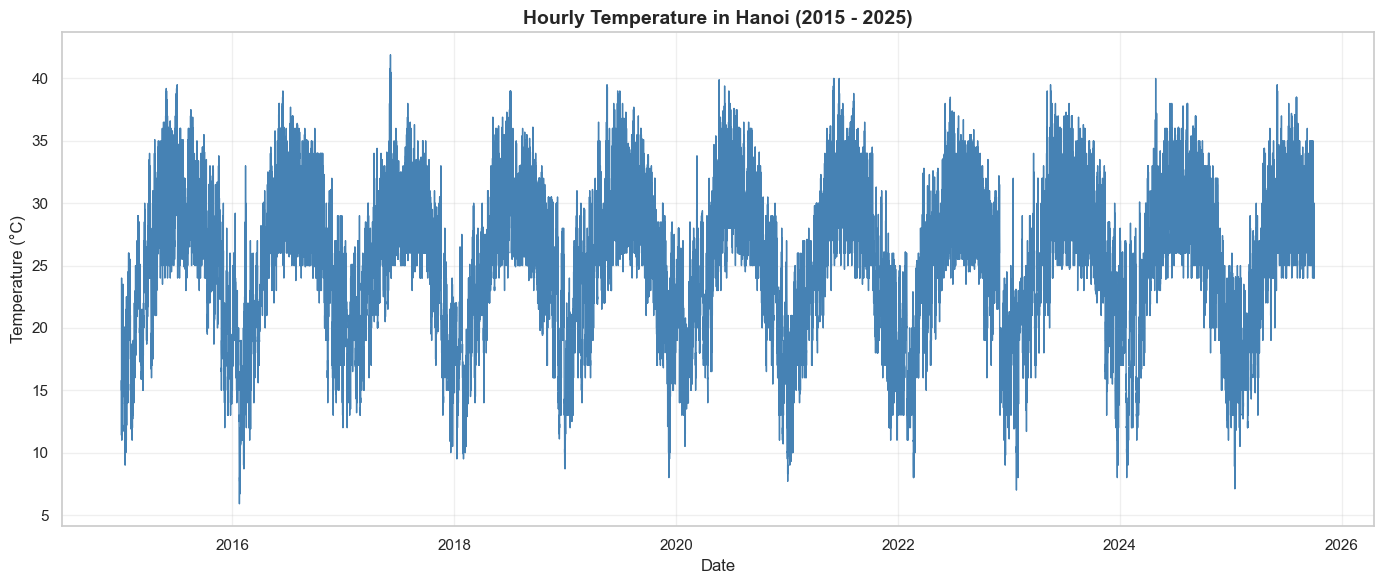

In [7]:
# Plot a line chart for the 'temp' column (target variable)
plt.figure(figsize=(14, 6))
plt.plot(df_hourly['datetime'], df_hourly['temp'], color='steelblue', linewidth=1)

# Customize display
plt.title("Hourly Temperature in Hanoi (2015 - 2025)", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

# Do not display legend
plt.show()

**Comparison: Hourly vs. Daily Temperature Charts**

| Feature                     | Hourly Temperature Chart                                                                 | Daily Temperature Chart                                                              |
|-----------------------------|--------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------|
| **Granularity**             | **Very High** (High-resolution). Provides 24 data points per day.                               | **Low** (Aggregated). Provides only 1 data point (average) per day.                          |
| **Diurnal (Day-Night) Cycle** | **Clearly visible.** Shows distinct “jagged” patterns (peaks in the afternoon, troughs in early morning). | **Completely lost.** Smoothed out by the averaging calculation.                              |
| **Volatility & Extremes**  | **Very High.** Shows the true extreme values (e.g., **5°C to 40°C**).                           | **Lower.** Temperature range is significantly narrowed (e.g., **9°C to 36°C**).              |
| **Seasonal Cycle**         | Still visible, but “masked” by the high-frequency day-night oscillations.                        | **Very clear and smooth.** This is the most prominent pattern.                               |
| **Chart Appearance**       | “Dense” and “noisy” (jagged).                                                                   | “Smooth”.                                                                                    |
| **Key Takeaway**           | Reveals **intra-day** dynamics and true volatility.                                              | Clearly shows **long-term** trends (weekly/seasonal/yearly).                                 |


In [8]:
# Save processed data
df_hourly.to_excel('../../data/processed/data_hourly_after_basic_understand.xlsx', index=False)

# 📊 Daily vs Hourly Dataset Comparison
| Aspect                       | Daily Dataset                                                     | Hourly Dataset                                                         |
| ---------------------------- | ----------------------------------------------------------------- | ---------------------------------------------------------------------- |
| **Granularity**              | Aggregated by day → smoother trends                               | High-resolution data by hour → more fluctuations                       |
| **Missing Values**           | Lower proportion of missing values                                | Higher missing rates in several variables                              |
| **Duplicates**               | Very few or none                                                  | Very few or none                                                       |
| **Outliers**                 | Fewer outliers thanks to daily aggregation                        | More outliers due to hourly variation and sudden changes               |
| **Stability**                | More stable, less noise                                           | More volatile and sensitive to short-term changes                      |
| **Feature Distribution**     | Distributions are smoother and more regular                       | Distributions are wider and often skewed                               |
| **Correlation Strength**     | Stronger correlations (daily aggregation amplifies relationships) | Weaker or less consistent correlations                                 |
| **Suitability for Modeling** | Good for long-term forecasting, trend analysis                    | Good for short-term forecasting, anomaly detection, real-time patterns |
| **Preprocessing Complexity** | Simple: fewer outliers, fewer missing values                      | More complex: requires more cleaning and robust scaling                |


**Overall Summary**

Overall, the Daily dataset provides a more stable and cleaner view of the data due to its aggregated nature, making it suitable for long-term forecasting and trend analysis. In contrast, the Hourly dataset offers detailed and dynamic information that captures short-term fluctuations but requires more extensive preprocessing, especially for handling missing values and outliers. Combining both datasets can deliver a more comprehensive perspective: Daily data captures long-term trends, while Hourly data reflects real-time variations and micro-patterns.